In [70]:
# pip install tensorflow datasets pillow 

In [13]:
from datasets import load_dataset
import os
import numpy as np
import matplotlib.pyplot as plt
import random
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models


In [14]:
# loading dataset
dataset = load_dataset("mnist")

In [15]:
# Function to save images into folders
def save_split(split, split_name):
    for i in range(10):
        os.makedirs(f"data/mnist_data/{split_name}/{i}", exist_ok=True)

    for idx, example in enumerate(split):
        image = example["image"]  # PIL image
        label = example["label"]
        image.save(f"data/mnist_data/{split_name}/{label}/{idx}.png")

In [16]:
# saving train & test images
save_split(dataset["train"], "train")
save_split(dataset["test"], "test")

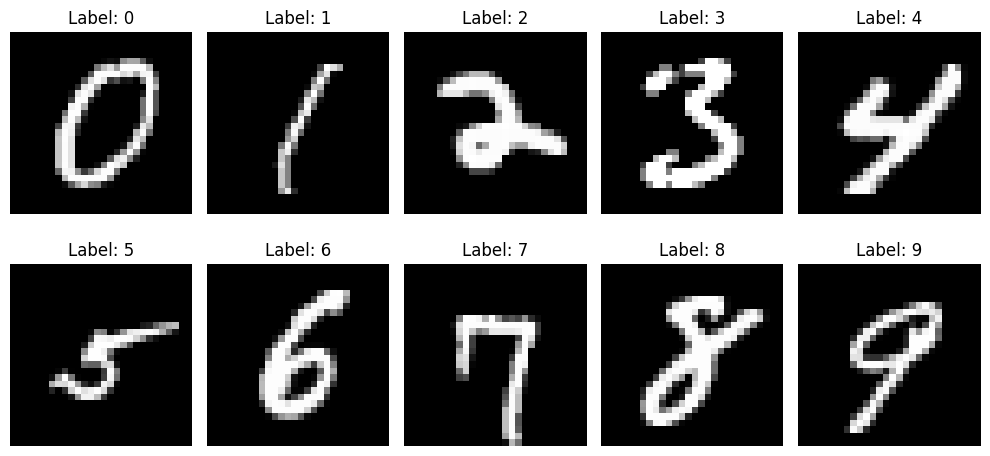

In [17]:
# displaying sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(10):
    label = str(i)
    folder = f"data/mnist_data/train/{label}"
    img_file = random.choice(os.listdir(folder))
    
    img = Image.open(os.path.join(folder, img_file))
    
    ax = axes[i // 5, i % 5]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [18]:
# loading data using keras
img_size = 28
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "data/mnist_data/train",
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    "data/mnist_data/test",
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical"
)

Found 60000 images belonging to 10 classes.
Found 10000 images belonging to 10 classes.


In [19]:
# defining CNN model
model = models.Sequential([
    layers.Input(shape=(28,28,1)),
    # block 1
    layers.Conv2D(16, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),
    
    # block 2
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    # block 3
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,618 (424.29 KB)

 Trainable params: 108,618 (424.29 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# compiling the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
# training the model
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2253s 1s/step - accuracy: 0.9535 - loss: 0.1567 - val_accuracy: 0.9813 - val_loss: 0.0570
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - accuracy: 0.9842 - loss: 0.0495 - val_accuracy: 0.9890 - val_loss: 0.0357
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9896 - loss: 0.0334 - val_accuracy: 0.9881 - val_loss: 0.0369
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - accuracy: 0.9916 - loss: 0.0255 - val_accuracy: 0.9891 - val_loss: 0.0332
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 39ms/step - accuracy: 0.9933 - loss: 0.0198 - val_accuracy: 0.9905 - val_loss: 0.0270


In [22]:
# model evaluation
loss, acc = model.evaluate(test_generator)
print(f"Test Accuracy: {acc:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9905 - loss: 0.0270
Test Accuracy: 0.99


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


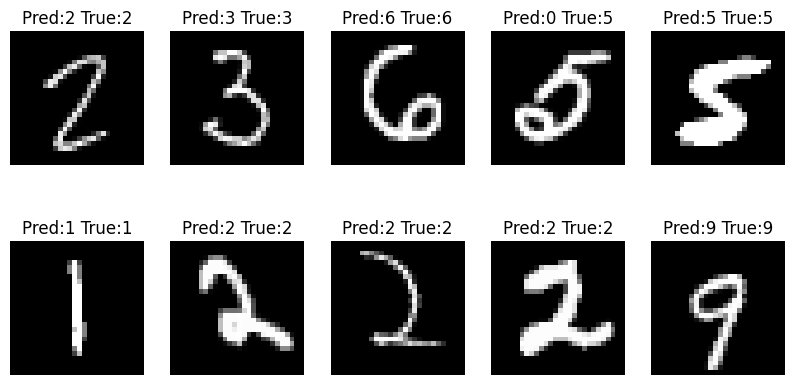

In [23]:
# making predictions
import numpy as np

# getting one batch
images, labels = next(test_generator)

predictions = model.predict(images)

# showing predictions
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i in range(10):
    ax = axes[i//5, i%5]
    ax.imshow(images[i].squeeze(), cmap='gray')
    
    pred_label = np.argmax(predictions[i])
    true_label = np.argmax(labels[i])
    
    ax.set_title(f"Pred:{pred_label} True:{true_label}")
    ax.axis("off")

plt.show()

**Exercise** 
1. Create 10 digit images (0–9). Draw them yourself and save as PNG/JPG. Preprocess each image accordingly and run predictions using your trained model. What is the model's performance?
2. Using the Fashion MNIST dataset, load and preprocess the data. Use the same CNN architecture from the MNIST exercise. Train the model for 5 epochs. Report model performance. (Use accuracy and F1 score)

Qn. 1

Create 10 digit images (0–9). Draw them yourself and save as PNG/JPG. Preprocess each image accordingly and run predictions using your trained model. What is the model's performance?

In [ ]:
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import center_of_mass

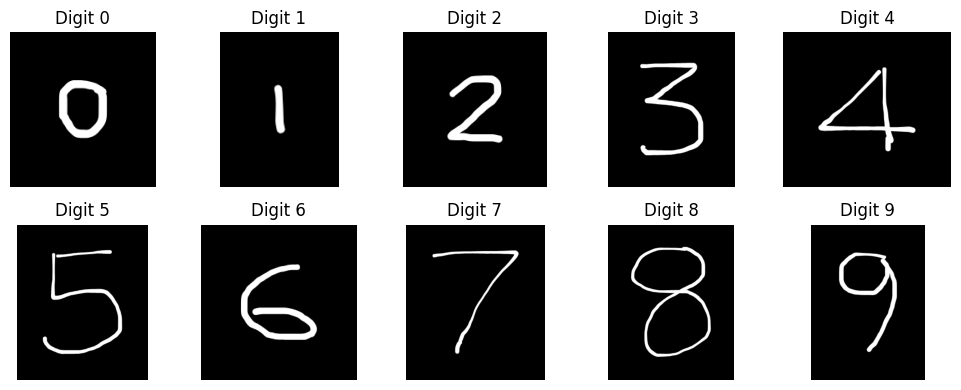

In [ ]:
# Displaying the raw images
plt.figure(figsize=(10, 4))

for i in range(10):
    path = f"my_digits/{i}.png"
    
    # Load raw image
    img = Image.open(path).convert("L")
    img = np.array(img)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Digit {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [64]:

# Preprocessing function for the image
def preprocess_image(path):
    # Loading
    img = Image.open(path).convert("L")
    img = np.array(img)

    # Normalizing
    img = img / 255.0

    # Threshold
    img = (img > 0.5).astype(np.uint8)

    # Cropping digit
    coords = np.column_stack(np.where(img > 0))
    
    if coords.size > 0:
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        img = img[y_min:y_max, x_min:x_max]

    # Resizing to 20x20
    img = cv2.resize(img, (20, 20))

    # Padding to 28x28
    img = np.pad(img, ((4,4),(4,4)), mode='constant')

    # Center using center of mass
    cy, cx = center_of_mass(img)

    shiftx = int(np.round(img.shape[1]/2 - cx))
    shifty = int(np.round(img.shape[0]/2 - cy))

    M = np.float32([[1, 0, shiftx], [0, 1, shifty]])
    img = cv2.warpAffine(img, M, (28, 28))

    # Converting to float32
    img = img.astype(np.float32)

    # Reshaping for CNN
    img = img.reshape(1, 28, 28, 1)

    return img

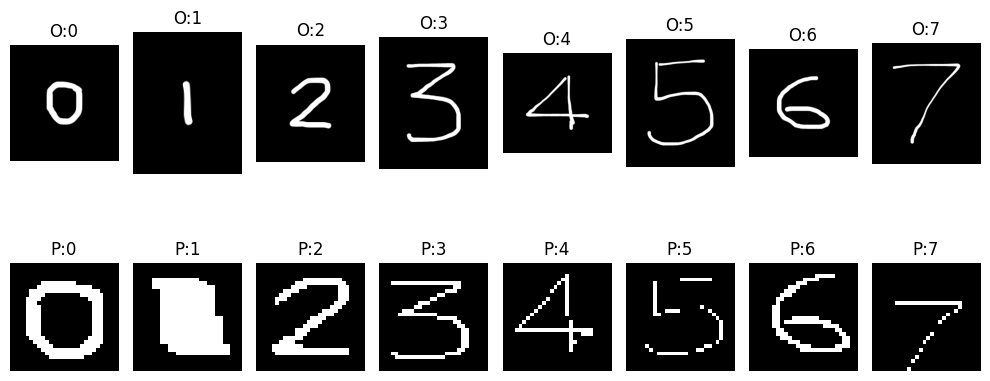

In [65]:
# Testing the preprocessing on one image
def show_all_digits():
    plt.figure(figsize=(10, 5))

    for i in range(8):
        path = f"my_digits/{i}.png"

        # Original image
        original = Image.open(path).convert("L")
        original = np.array(original)

        # Processed image
        processed = preprocess_image(path).reshape(28, 28)

        # Row 1 to original
        plt.subplot(2, 8, i + 1)
        plt.imshow(original, cmap='gray')
        plt.title(f"O:{i}")
        plt.axis('off')

        # Row 2 to processed
        plt.subplot(2, 8, i + 9)
        plt.imshow(processed, cmap='gray')
        plt.title(f"P:{i}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Call it
show_all_digits()

In [66]:
# Predicting the digit using the trained model
def predict_digit(path, model):
    img = preprocess_image(path)
    prediction = model.predict(img)
    predicted_label = np.argmax(prediction)
    confidence = np.max(prediction)

    return predicted_label, confidence

In [67]:
correct = 0

for i in range(10):
    path = f"my_digits/{i}.png"
    
    pred, conf = predict_digit(path, model)
    
    print(f"Actual: {i} | Predicted: {pred} | Confidence: {conf:.4f}")
    
    if pred == i:
        correct += 1

accuracy = correct / 10
print("\nFinal Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Actual: 0 | Predicted: 0 | Confidence: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Actual: 1 | Predicted: 2 | Confidence: 0.9658
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Actual: 2 | Predicted: 2 | Confidence: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Actual: 3 | Predicted: 3 | Confidence: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Actual: 4 | Predicted: 4 | Confidence: 0.9992
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Actual: 5 | Predicted: 5 | Confidence: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Actual: 6 | Predicted: 6 | Confidence: 0.9941
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
Actual: 7 | Predicted: 7 | Confidence: 0.9997
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Actual: 8 | Predicted: 2 | Confidence: 0.7841
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Actual: 9 | Predicted: 9 | Confidence: 0.7461

Final Accuracy: 0.8


Qn.2

Using the Fashion MNIST dataset, load and preprocess the data. Use the same CNN architecture from the MNIST exercise. Train the model for 5 epochs. Report model performance. (Use accuracy and F1 score)

In [78]:
from sklearn.metrics import f1_score
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


In [69]:
# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 5us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [71]:
# Normalizing
X_train = X_train / 255.0
X_test = X_test / 255.0

In [72]:
# Reshaping for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [73]:
# One-hot encoding labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [ ]:
# Defining CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

c:\Users\byamu\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [75]:
# Compiling the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [76]:
# Training the model
history = model.fit(
    X_train, y_train_cat,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test_cat)
)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 37s 35ms/step - accuracy: 0.8252 - loss: 0.4887 - val_accuracy: 0.8623 - val_loss: 0.3818
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - accuracy: 0.8832 - loss: 0.3216 - val_accuracy: 0.8845 - val_loss: 0.3144
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.8992 - loss: 0.2751 - val_accuracy: 0.8979 - val_loss: 0.2826
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - accuracy: 0.9096 - loss: 0.2446 - val_accuracy: 0.8997 - val_loss: 0.2690
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.9179 - loss: 0.2212 - val_accuracy: 0.9027 - val_loss: 0.2649


In [ ]:
# Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

# F1 Score
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Test Accuracy: {test_acc:.4f}")
print(f"F1 Score (Macro): {f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Test Accuracy: 0.9027
F1 Score (Macro): 0.9010


The model achieved 90.27% accuracy, indicating strong performance in classifying fashion items.
The F1 score 0.9010 confirms that the model performs consistently across all classes